
# Edward Moswane Project 1: Data Collection and Initial Analysis of Stock Market Data

Colab Link:

https://colab.research.google.com/drive/1_lwQL7XEVcShFP6stfTh_0mAvxMK2Q3I?usp=sharing

In [ ]:
# Loading and Understanding both Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:


# Loading both two datasets
stocks = pd.read_csv('/content/historical_stocks.csv')
stock_prices = pd.read_csv('/content/historical_stock_prices.csv')

# Showing both five rows of both dataset
print("Historical Stocks Dataset:")
display(stocks.head())

Historical Stocks Dataset:


,ticker,exchange,name,sector,industry
0,PIH,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
1,PIHPP,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
2,TURN,NASDAQ,180 DEGREE CAPITAL CORP.,FINANCE,FINANCE/INVESTORS SERVICES
3,FLWS,NASDAQ,"1-800 FLOWERS.COM, INC.",CONSUMER SERVICES,OTHER SPECIALTY STORES
4,FCCY,NASDAQ,1ST CONSTITUTION BANCORP (NJ),FINANCE,SAVINGS INSTITUTIONS


In [ ]:
print("\nHistorical Stock Prices Dataset:")
display(stock_prices.head())


Historical Stock Prices Dataset:


,ticker,open,close,adj_close,low,high,volume,date
0,AHH,11.50,11.58,8.493155,11.25,11.68,4633900.0,2013-05-08
1,AHH,11.66,11.55,8.471151,11.50,11.66,275800.0,2013-05-09
2,AHH,11.55,11.60,8.507822,11.50,11.60,277100.0,2013-05-10
3,AHH,11.63,11.65,8.544494,11.55,11.65,147400.0,2013-05-13
4,AHH,11.60,11.53,8.456484,11.50,11.60,184100.0,2013-05-14


Show information about each dataset


In [ ]:
print("Historical Stocks Dataset Information:")
stocks.info()

Historical Stocks Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6460 entries, 0 to 6459
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ticker    6460 non-null   object
 1   exchange  6460 non-null   object
 2   name      6460 non-null   object
 3   sector    5020 non-null   object
 4   industry  5020 non-null   object
dtypes: object(5)
memory usage: 252.5+ KB


In [ ]:
print("\nHistorical Stock Prices Dataset Information:")
stock_prices.info()


Historical Stock Prices Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127578 entries, 0 to 127577
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   ticker     127578 non-null  object 
 1   open       127578 non-null  float64
 2   close      127578 non-null  float64
 3   adj_close  127578 non-null  float64
 4   low        127577 non-null  float64
 5   high       127577 non-null  float64
 6   volume     127577 non-null  float64
 7   date       127577 non-null  object 
dtypes: float64(6), object(2)
memory usage: 7.8+ MB


Part 1 Load and Understand the Data

1. What does each dataset represent?  
The historical_stocks dataset have information about securities, including related ticker, exchange, name, sector, and industry. The historical_stock_prices dataset has daily trading information, including open, high, low, close, adjusted close, volume, and date.

2. What is the purpose of the ticker column?
The ticker is the symbol we use to identify a specific stock or security. The ricker is also used It is also used to connect the two datasets.

3. How are the two datasets related?
These two datasets are related through the ticker column. The historical stock dataset provides information about the security. The historical price dataset provides its historical daily trading information.

4. How many rows and columns does each dataset contain?
The historical stocks dataset comprises of 6,460 rows and 5 columns. The historical stock prices dataset comprises of 1,598,956 rows and 8 columns.

5. Which columns are numerical?  
In the historical price dataset, `open`, `close`, `adj_close`, `low`, `high`, and `volume` are numerical variables.

6. Which columns are categorical?
In the historical stocks dataset, `ticker`, `exchange`, `name`, `sector`, and `industry` are categorical variables. In the historical price dataset, `ticker` is categorical and `date` is a date/time variable.

7. Which column represents the date?
The `date` column .

Part 2 — Check Data Quality

In [ ]:
# Checking for missing values in both datasets

print("Missing values in historical_stocks:")
display(stocks.isnull().sum())

Missing values in historical_stocks:


,0
ticker,0
exchange,0
name,0
sector,1440
industry,1440


In [ ]:
print("\nMissing values in historical_stock_prices:")
display(stock_prices.isnull().sum())


Missing values in historical_stock_prices:


,0
ticker,0
open,0
close,0
adj_close,0
low,1
high,1
volume,1
date,1


In [ ]:
# Removing the single incomplete price record
before_cleaning = len(stock_prices)

stock_prices = stock_prices.dropna(
    subset=['date', 'adj_close', 'low', 'high', 'volume']).copy()

after_cleaning = len(stock_prices)

print("Rows before cleaning:", before_cleaning)
print("Rows after cleaning:", after_cleaning)
print("Rows removed:", before_cleaning - after_cleaning)

Rows before cleaning: 127578
Rows after cleaning: 127577
Rows removed: 1


In [ ]:
print("Remaining missing values:")
display(stock_prices.isna().sum())

Remaining missing values:


,0
ticker,0
open,0
close,0
adj_close,0
low,0
high,0
volume,0
date,0


Cleaning Decision for Missing Price Data

One price record has missing values for the date, adjusted close, low, high, and volume fields. I have decided to remove it because the record is incomplete.

However, the missing sector and industry values in the stock information dataset were left untouched because we can identify stock records. The missing classification information does not necessarily indicate an invalid security.

In [ ]:
# Checking for duplicate rows

print("Duplicate rows in historical_stocks:", stocks.duplicated().sum())
print("Duplicate rows in historical_stock_prices:", stock_prices.duplicated().sum())

Duplicate rows in historical_stocks: 0
Duplicate rows in historical_stock_prices: 0


In [ ]:
# Checking for duplicate ticker  and date combinations

duplicate_ticker_date = stock_prices.duplicated(
    subset=['ticker', 'date']).sum()

print("Duplicate ticker + date combinations:",
      duplicate_ticker_date)

Duplicate ticker + date combinations: 0


Check Suspicious Records

In [ ]:
# Checking for potentially suspicious price records

suspicious_prices = stock_prices[
    (stock_prices['open'] <= 0) |
    (stock_prices['close'] <= 0) |
    (stock_prices['low'] <= 0) |
    (stock_prices['high'] <= 0) |
    (stock_prices['high'] < stock_prices['low']) |
    (stock_prices['volume'] < 0)]

print("Potentially suspicious price records:",
      len(suspicious_prices))

display(suspicious_prices.head(10))

Potentially suspicious price records: 0


,ticker,open,close,adj_close,low,high,volume,date


In [ ]:
# Investigating the records only for Open or Close that fall outside the High-Low range

invalid_range = stock_prices[
    (stock_prices['open'] < stock_prices['low']) |
    (stock_prices['open'] > stock_prices['high']) |
    (stock_prices['close'] < stock_prices['low']) |
    (stock_prices['close'] > stock_prices['high'])].copy()

print("Number of records requiring investigation:",
      len(invalid_range))

display(invalid_range[['ticker', 'date', 'open', 'high', 'low', 'close', 'volume']].head(20))

Number of records requiring investigation: 0


,ticker,date,open,high,low,close,volume


In [ ]:
# Checking for tickers that are responsible for the unusual records

invalid_ticker_counts = (invalid_range['ticker'].value_counts().head(10))

print("Tickers that require Investigation:")
display(invalid_ticker_counts)

Tickers that require Investigation:


,count
ticker,


Checking whether prices fall within High/Low

In [ ]:
# Checking whether open and close prices are within the daily high or low range

invalid_open = (
    (stock_prices['open'] < stock_prices['low']) |
    (stock_prices['open'] > stock_prices['high'])).sum()

invalid_close = (
    (stock_prices['close'] < stock_prices['low']) |
    (stock_prices['close'] > stock_prices['high'])).sum()

print("Records where Open is outside Low-High range:", invalid_open)
print("Records where Close is outside Low-High range:", invalid_close)

Records where Open is outside Low-High range: 0
Records where Close is outside Low-High range: 0


Cleaning decision

The data-quality checks and exploring were performed before making any signficant decision. Missing values were investigated before being deleted. Deleted only one record because there was an obvious data-quality problem identified.

Part 3 - Prepare and Explore the Date

In [ ]:
# Converting the date column to datetime

stock_prices['date'] = pd.to_datetime(stock_prices['date'],errors='coerce')

# Checking the data type
print("Date data type:")
print(stock_prices['date'].dtype)

# Finding the date range
earliest_date = stock_prices['date'].min()
latest_date = stock_prices['date'].max()

print("\nEarliest date:", earliest_date)
print("Latest date:", latest_date)

Date data type:
datetime64[ns]

Earliest date: 1973-05-03 00:00:00
Latest date: 2018-08-24 00:00:00


In [ ]:
# Counting invalid or missing dates after conversion

print("Missing or invalid dates:",stock_prices['date'].isna().sum())

Missing or invalid dates: 0


Interpretation

Converting the date column to datetime is important because it makes it easier to sort observations in chronologically order and perform time-based analysis. It also allows analysis by year or month, and other time periods. However, the actual date range reported is based on the historical stock-price dataset.

Part 4 - Explore Categorical Data

4.1 Stock Exchanges: The historical stock dataset is examined to determine how securities are distributed across exchanges.

In [ ]:
# Counting securities by exchange
exchange_counts = stocks['exchange'].value_counts()

print("Number of securities by exchange:")
display(exchange_counts)

Number of securities by exchange:


,count
exchange,
NASDAQ,3308
NYSE,3152


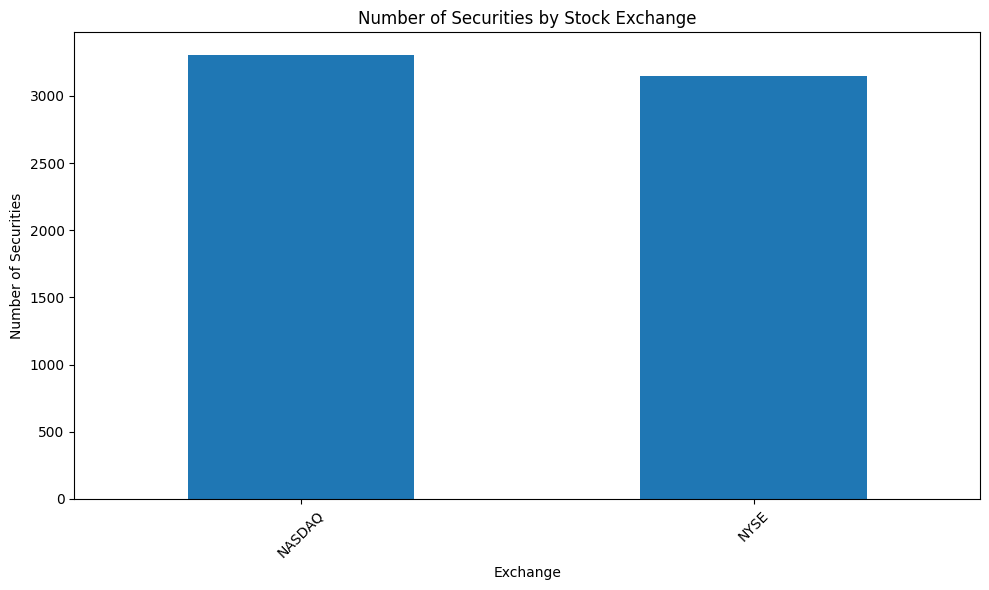

In [ ]:
# Bar Chart of securities by exchange

plt.figure(figsize=(10, 6))

exchange_counts.plot(kind='bar')

plt.title('Number of Securities by Stock Exchange')
plt.xlabel('Exchange')
plt.ylabel('Number of Securities')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print("Exchange with the most securities:",exchange_counts.idxmax())
print("Number of securities:",exchange_counts.max())

Exchange with the most securities: NASDAQ
Number of securities: 3308


4.2. Sectors

In [ ]:
# Count securities by sector
sector_counts = stocks['sector'].value_counts(dropna=False)

print("Number of Securities by Sector:")
display(sector_counts)

Number of Securities by Sector:


,count
sector,
NaN,1440
FINANCE,1022
CONSUMER SERVICES,796
HEALTH CARE,784
TECHNOLOGY,607
CAPITAL GOODS,352
ENERGY,286
PUBLIC UTILITIES,273
BASIC INDUSTRIES,272


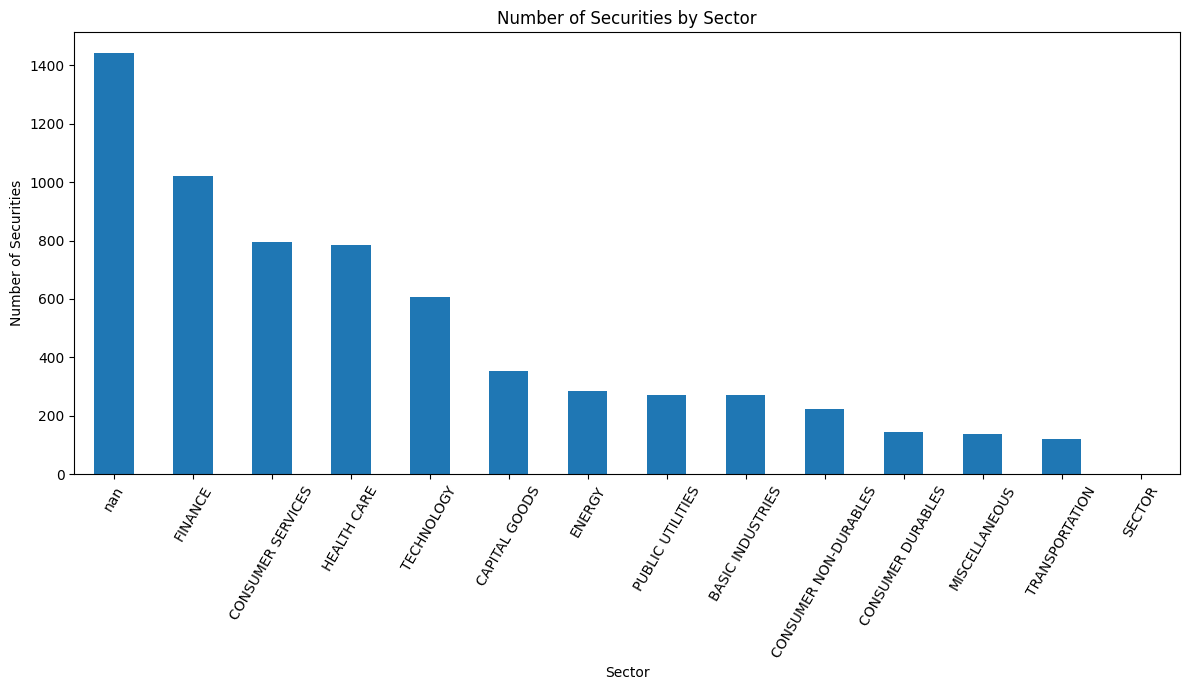

In [ ]:
plt.figure(figsize=(12, 7))

sector_counts.dropna().plot(kind='bar')

plt.title('Number of Securities by Sector')
plt.xlabel('Sector')
plt.ylabel('Number of Securities')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

In [ ]:
missing_sector = stocks['sector'].isna().sum()

print("Securities with missing sector information:",missing_sector)

Securities with missing sector information: 1440


Interpretation

The distributions show how the securities in the dataset are categorized. Missing sector information does not necessarily imply that the record is incorrect. It could be result from incomplete classification information or differences in how securities were categorized in the source data.

Part 5 - Explore Numerical Data

In [ ]:
# Descriptive statistics

numeric_columns = ['open','high','low','close','volume']

summary_statistics = stock_prices[numeric_columns].describe().T

summary_statistics

,count,mean,std,min,25%,50%,75%,max
open,127577.0,1.667681e+01,2.781850e+01,0.124128,5.250000,10.75,19.209999,6.860068e+02
high,127577.0,1.693592e+01,2.849479e+01,0.125867,5.399270,10.94,19.510000,6.981654e+02
low,127577.0,1.640209e+01,2.699964e+01,0.123261,5.144628,10.55,18.900000,6.439135e+02
close,127577.0,1.666758e+01,2.771962e+01,0.123261,5.260000,10.75,19.209999,6.668089e+02
volume,127577.0,7.139531e+06,3.309423e+07,100.000000,28600.000000,121200.00,510100.000000,1.855410e+09


In [ ]:
# Mean and median closing price

mean_close = stock_prices['close'].mean()
median_close = stock_prices['close'].median()

print("Mean closing price:", mean_close)
print("Median closing price:", median_close)

print("\nSignificant Difference between Mean and Median:",mean_close - median_close)

Mean closing price: 16.66757651112656
Median closing price: 10.75

Significant Difference between Mean and Median: 5.917576511126558


In [ ]:
# Standard Deviation for each numerical variable
std_values = stock_prices[numeric_columns].std()

print("Standard deviations:")
display(std_values)

print("\nVariable with the largest standard deviation:",std_values.idxmax())

Standard deviations:


,0
open,2.781850e+01
high,2.849479e+01
low,2.699964e+01
close,2.771962e+01
volume,3.309423e+07



Variable with the largest standard deviation: volume


In [ ]:
# Maximum values of for the stock prices
max_values = stock_prices[numeric_columns].max()

print("Maximum_ Values:")
display(max_values)

Maximum_ Values:


,0
open,6.860068e+02
high,6.981654e+02
low,6.439135e+02
close,6.668089e+02
volume,1.855410e+09


Short Interpretation

The descriptive statistics gives us information about the central tendency, spread, and range of the numerical variables.

The mean and median closing prices are compared to find out whether the closing-price distribution may be affected by skewness or extreme observations. A signficant difference between mean and median can indicate a skewed distribution or the presence of unusually large or unusual small observations.

Part 6 - Investigate Unusual Values

6.1 Highest Closing Prices

In [ ]:
# Finding the observations with the highest closing prices

highest_close = stock_prices.nlargest(10,'close')[['ticker', 'date', 'open', 'high','low', 'close', 'volume']]

display(highest_close)

,ticker,date,open,high,low,close,volume
34184,VIAV,2000-03-06,643.913513,686.291260,643.913513,666.808899,4242700.0
34205,VIAV,2000-03-07,686.006836,698.165405,617.605225,653.868042,5100600.0
34118,VIAV,2000-03-01,624.573364,643.060303,613.765625,639.078491,3724400.0
34162,VIAV,2000-03-03,647.610901,648.179749,631.399292,637.087585,2844600.0
34271,VIAV,2000-03-10,617.463013,648.464172,591.581360,627.986328,4660100.0
34140,VIAV,2000-03-02,643.913513,650.099426,605.802063,621.160400,3609500.0
34227,VIAV,2000-03-08,667.804321,668.941956,602.957886,621.160400,7499100.0
34249,VIAV,2000-03-09,610.921509,626.564270,596.416382,620.022766,4159600.0
36265,VIAV,2000-07-26,593.856628,639.362915,587.030701,618.600708,21002100.0
36199,VIAV,2000-07-21,576.293945,626.279846,573.947693,613.481201,14247500.0


In [ ]:
print("Tickers associated with the highest closing prices:")

display(highest_close['ticker'].value_counts())

Tickers associated with the highest closing prices:


,count
ticker,
VIAV,10


Shot Interpretation of Highest Closing Prices

The observations with the highest closing prices were investigated using ticker, date, open, high, low, close, and volume. A high closing price by itself does not show that a record is erroneous. These observations will be documented rather than being removed.

6.2 Largest Adjusted Closing Prices

In [ ]:
# Finding observations with the largest adjusted closing prices

highest_adj_close = stock_prices.nlargest(10,'adj_close')[['ticker', 'date', 'close', 'adj_close', 'volume']]

display(highest_adj_close)

,ticker,date,close,adj_close,volume
34184,VIAV,2000-03-06,666.808899,666.808899,4242700.0
34205,VIAV,2000-03-07,653.868042,653.868042,5100600.0
34118,VIAV,2000-03-01,639.078491,639.078491,3724400.0
34162,VIAV,2000-03-03,637.087585,637.087585,2844600.0
34271,VIAV,2000-03-10,627.986328,627.986328,4660100.0
34140,VIAV,2000-03-02,621.160400,621.160400,3609500.0
34227,VIAV,2000-03-08,621.160400,621.160400,7499100.0
34249,VIAV,2000-03-09,620.022766,620.022766,4159600.0
36265,VIAV,2000-07-26,618.600708,618.600708,21002100.0
36199,VIAV,2000-07-21,613.481201,613.481201,14247500.0


Shot Interpretation of Adjusted Closing Prices

Adjusted closing prices can differ signficantly from the regular closing price. The observations with the largest adjusted closing values were investigated by comparing the adjusted close, regular close, ticker, date, and trading volume.

In my opinion, an unusually large adjusted closing value should not automatically be considered an error. Further investigation should be taken before removing such an observation.

Part 7 — Visualize the Data

7.1 Closing Price Histogram

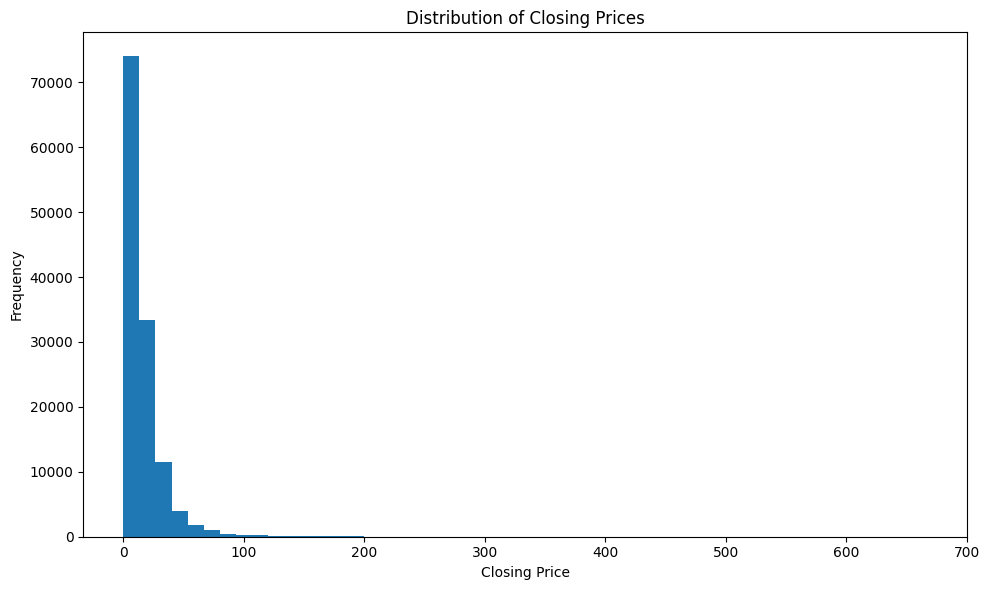

In [ ]:
# Closing price histogram
plt.figure(figsize=(10, 6))

stock_prices['close'].dropna().sample(n=min(200000, stock_prices['close'].notna().sum()),
    random_state=42).plot(kind='hist',bins=50)

plt.title('Distribution of Closing Prices')
plt.xlabel('Closing Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

7.2 Volume Histogram

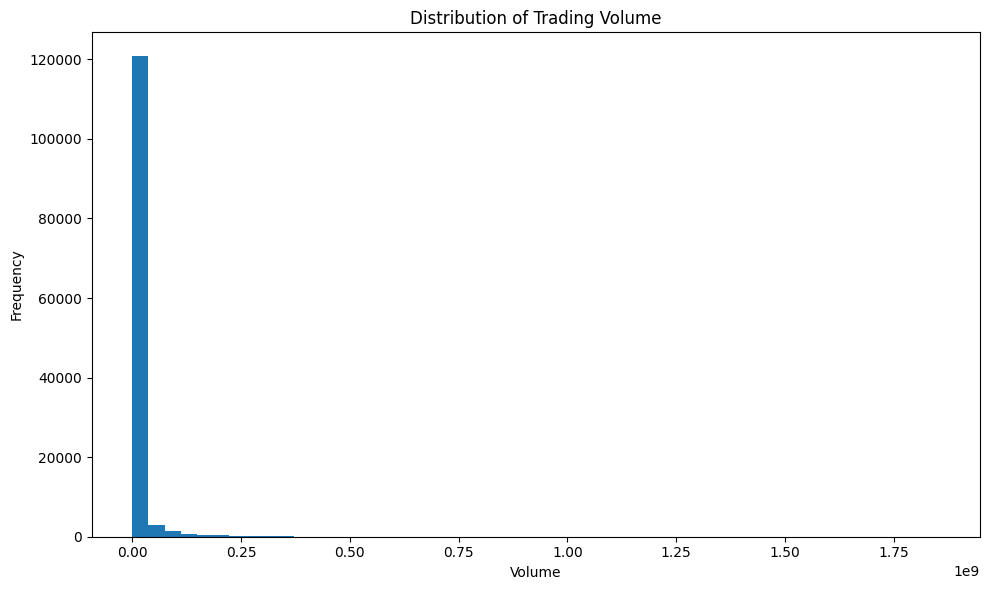

In [ ]:
# Volume Histogram
plt.figure(figsize=(10, 6))

stock_prices['volume'].dropna().sample(n=min(200000, stock_prices['volume'].notna().sum()),
    random_state=42).plot(kind='hist',bins=50)

plt.title('Distribution of Trading Volume')
plt.xlabel('Volume')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Visualization Interpretation

Both closing-price and trading-volume histograms are extremly right-skewed. Most observations are concentrated at low values, while a small number of extreme observations create long right tails. The boxplot also show the same pattern. This imply numerous high-value outliers. The large difference between the mean and median closing price further supports the presence of extreme observations in the dataset.

7.3 Closing Price Boxplot

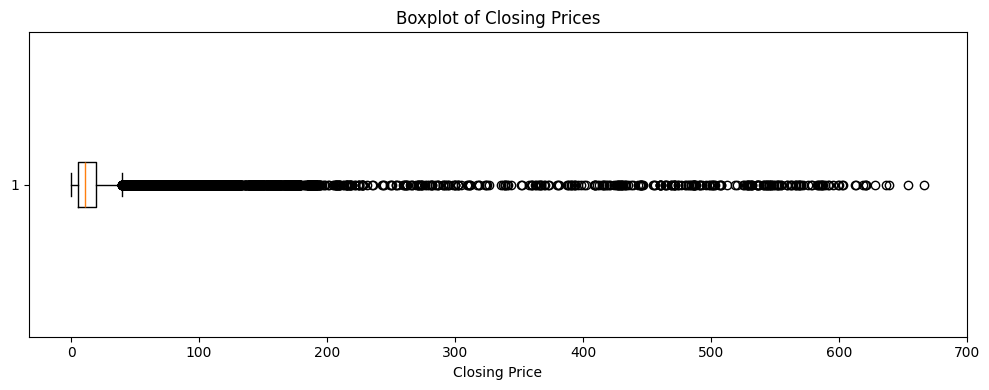

In [ ]:
# Closing price boxplot
close_sample = stock_prices['close'].dropna().sample(
    n=min(200000, stock_prices['close'].notna().sum()),random_state=42)

plt.figure(figsize=(10, 4))
plt.boxplot(close_sample, vert=False)

plt.title('Boxplot of Closing Prices')
plt.xlabel('Closing Price')
plt.tight_layout()
plt.show()

Volume Boxplot

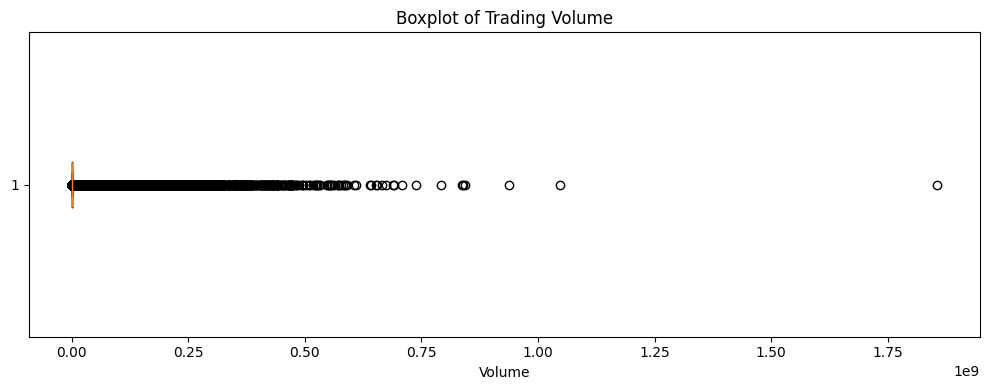

In [ ]:
# Volume boxplot
volume_sample = stock_prices['volume'].dropna().sample(
    n=min(200000, stock_prices['volume'].notna().sum()),random_state=42)

plt.figure(figsize=(10, 4))
plt.boxplot(volume_sample, vert=False)
plt.title('Boxplot of Trading Volume')
plt.xlabel('Volume')
plt.tight_layout()
plt.show()

 Interpretation

The boxplots provide another view of the spread and potential extreme observations, supporting the box plot.

This visualizations should be compared with the descriptive statistics from above. Large differences between the mean and median, together with long tails, can indicate strong skewness and extreme observations.

Part 8 — Explore One Stock

For this section, I selected the ticker AHH and examined its closing price over time.

In [ ]:
# Chosen one stock
selected_ticker = 'AHH'

ahh = stock_prices[stock_prices['ticker'] == selected_ticker].copy()

# Sorting by date
ahh = ahh.sort_values('date')

print("Selected ticker:", selected_ticker)
print("Number of observations:", len(ahh))

display(ahh.head())

Selected ticker: AHH
Number of observations: 1336


,ticker,open,close,adj_close,low,high,volume,date
0,AHH,11.50,11.58,8.493155,11.25,11.68,4633900.0,2013-05-08
1,AHH,11.66,11.55,8.471151,11.50,11.66,275800.0,2013-05-09
2,AHH,11.55,11.60,8.507822,11.50,11.60,277100.0,2013-05-10
3,AHH,11.63,11.65,8.544494,11.55,11.65,147400.0,2013-05-13
4,AHH,11.60,11.53,8.456484,11.50,11.60,184100.0,2013-05-14


Line Chart

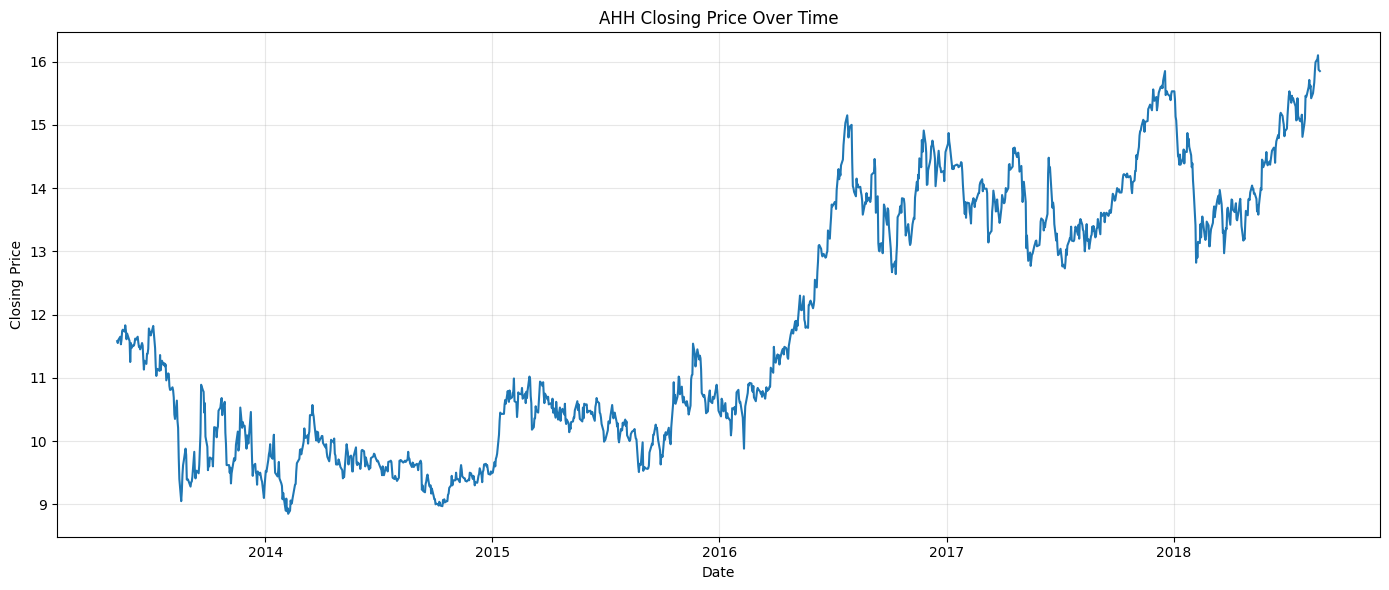

In [ ]:
# Closing price over time
plt.figure(figsize=(14, 6))

plt.plot(ahh['date'],ahh['close'])
plt.title(f'{selected_ticker} Closing Price Over Time')

plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Highest and Lowest periods

In [ ]:
# Highest and lowest closing prices for AHH

highest_ahh = ahh.loc[ahh['close'].idxmax()]

lowest_ahh = ahh.loc[ahh['close'].idxmin()]

print("Highest closing price:")
display(highest_ahh)

print("\nLowest closing price:")
display(lowest_ahh)

Highest closing price:


,11799
ticker,AHH
open,16.02
close,16.1
adj_close,16.1
low,15.98
high,16.17
volume,235400.0
date,2018-08-21 00:00:00



Lowest closing price:


,234
ticker,AHH
open,8.97
close,8.85
adj_close,6.750713
low,8.85
high,8.98
volume,104700.0
date,2014-02-07 00:00:00


Checking for Gaps

In [ ]:
# Checking for gaps between trading observations
ahh_dates = ahh['date'].dropna().sort_values()

date_differences = ahh_dates.diff().dt.days

print("Largest gap between observations:",
      date_differences.max(), "days")

print("\nLargest gaps:")
display(date_differences.nlargest(10))

Largest gap between observations: 4.0 days

Largest gaps:


,date
13,4.0
91,4.0
221,4.0
240,4.0
283,4.0
474,4.0
589,4.0
993,4.0
1992,4.0
2160,4.0


### Interpretation

The selected stock's closing-price chart shows how its market price changed over the available historical period. The highest and lowest closing-price observations were identified to highlight periods of unusually high or low prices.

Available gaps in the dataset occur because in real world stock markets do not trade every calendar day. Also, information such as company announcements, earnings reports, economic conditions, market events, and trading activity would be signficant for explaining major price movements.

# Final Summary of Findings Report

In [ ]:
print("\nDATASETS")
print("Historical stocks rows:", stocks.shape[0])
print("Historical stocks columns:", stocks.shape[1])
print("Historical stock prices rows:", stock_prices.shape[0])
print("Historical stock prices columns:", stock_prices.shape[1])

print("\nDATE RANGE")
print("Earliest date:", earliest_date)
print("Latest date:", latest_date)

print("\nDATA QUALITY")
print("Duplicate stock rows:", stocks.duplicated().sum())
print("Duplicate price rows:", stock_prices.duplicated().sum())
print("Duplicate ticker-date combinations:",
      duplicate_ticker_date)

print("\nMISSING VALUES")
print("Missing sector values:", stocks['sector'].isna().sum())
print("Missing industry values:", stocks['industry'].isna().sum())
print("Missing price values:")
display(stock_prices.isna().sum())

print("\nCLOSING PRICE")
print("Mean:", mean_close)
print("Median:", median_close)
print("Difference:", mean_close - median_close)

print("\nLARGEST STANDARD DEVIATION")
print(std_values.idxmax())
print(std_values.max())

print("\nHIGHEST CLOSING PRICE")
display(highest_close.head(5))

print("\nLARGEST ADJUSTED CLOSING PRICE")
display(highest_adj_close.head(5))

print("\nSELECTED STOCK")
print("Ticker:", selected_ticker)
print("Observations:", len(ahh))
print("Highest close:", highest_ahh['close'])
print("Highest close date:", highest_ahh['date'])
print("Lowest close:", lowest_ahh['close'])
print("Lowest close date:", lowest_ahh['date'])
print("Largest date gap:", date_differences.max(), "days")


DATASETS
Historical stocks rows: 6460
Historical stocks columns: 5
Historical stock prices rows: 127577
Historical stock prices columns: 8

DATE RANGE
Earliest date: 1973-05-03 00:00:00
Latest date: 2018-08-24 00:00:00

DATA QUALITY
Duplicate stock rows: 0
Duplicate price rows: 0
Duplicate ticker-date combinations: 0

MISSING VALUES
Missing sector values: 1440
Missing industry values: 1440
Missing price values:


,0
ticker,0
open,0
close,0
adj_close,0
low,0
high,0
volume,0
date,0



CLOSING PRICE
Mean: 16.66757651112656
Median: 10.75
Difference: 5.917576511126558

LARGEST STANDARD DEVIATION
volume
33094234.40683258

HIGHEST CLOSING PRICE


,ticker,date,open,high,low,close,volume
34184,VIAV,2000-03-06,643.913513,686.291260,643.913513,666.808899,4242700.0
34205,VIAV,2000-03-07,686.006836,698.165405,617.605225,653.868042,5100600.0
34118,VIAV,2000-03-01,624.573364,643.060303,613.765625,639.078491,3724400.0
34162,VIAV,2000-03-03,647.610901,648.179749,631.399292,637.087585,2844600.0
34271,VIAV,2000-03-10,617.463013,648.464172,591.581360,627.986328,4660100.0



LARGEST ADJUSTED CLOSING PRICE


,ticker,date,close,adj_close,volume
34184,VIAV,2000-03-06,666.808899,666.808899,4242700.0
34205,VIAV,2000-03-07,653.868042,653.868042,5100600.0
34118,VIAV,2000-03-01,639.078491,639.078491,3724400.0
34162,VIAV,2000-03-03,637.087585,637.087585,2844600.0
34271,VIAV,2000-03-10,627.986328,627.986328,4660100.0



SELECTED STOCK
Ticker: AHH
Observations: 1336
Highest close: 16.1000003814697
Highest close date: 2018-08-21 00:00:00
Lowest close: 8.85000038146973
Lowest close date: 2014-02-07 00:00:00
Largest date gap: 4.0 days


### Interpretation of CTIC

The highest closing prices in the dataset are associated with ticker CTIC. There are several observations occurring in 2000. The highest recorded closing price is $800,250 on September 29, 2000, and trading volume of 100 shares. Observations were therefore retained because additional historical information would be required to determine whether they resulted from a corporate action, price adjustment, or another historical market.

Future Questions and Hypotheses

Hypothesis 1: Does trading volume change significantly when periods of large stock-price movements change?

Hypothesis 2: Do stocks from different sectors show a significant different levels of price volatility?

Part 9 — Data Segmentation and Analysis by Decade

In [ ]:
# creating a copy of the cleaned price dataset
decade_data = stock_prices.copy()

# creating sure date is in datetime format
decade_data['date'] = pd.to_datetime(decade_data['date'])

# Creating a decade column
decade_data['decade'] = (decade_data['date'].dt.year // 10) * 10

# showing the decades found in the dataset
print("Decades represented in the dataset:")
print(sorted(decade_data['decade'].unique()))

# Creating separate DataFrames for each decade
decades = {}

for decade in sorted(decade_data['decade'].unique()):
    decades[decade] = decade_data[decade_data['decade'] == decade].copy()

# showing number of observations in each decade
print("\nNumber of Observations by Decade:")

for decade, df in decades.items():
    print(f"{decade}s: {len(df):,} observations")

Decades represented in the dataset:
[np.int32(1970), np.int32(1980), np.int32(1990), np.int32(2000), np.int32(2010)]

Number of Observations by Decade:
1970s: 532 observations
1980s: 11,241 observations
1990s: 19,948 observations
2000s: 43,633 observations
2010s: 52,223 observations


9.1 Merge Stock Prices with Stock Information

In [ ]:
# Merging using ticker
merged_data = decade_data.merge(
    stocks[['ticker', 'exchange', 'name', 'sector', 'industry']],on='ticker',how='left')

print("Merged dataset shape:", merged_data.shape)
print("\nFirst five rows of merged dataset:")

display(merged_data.head())
print("\nSector information after merging:")
display(merged_data['sector'].value_counts(dropna=False).head(15))

Merged dataset shape: (127577, 13)

First five rows of merged dataset:


,ticker,open,close,adj_close,low,high,volume,date,decade,exchange,name,sector,industry
0,AHH,11.50,11.58,8.493155,11.25,11.68,4633900.0,2013-05-08,2010,NYSE,"ARMADA HOFFLER PROPERTIES, INC.",FINANCE,REAL ESTATE
1,AHH,11.66,11.55,8.471151,11.50,11.66,275800.0,2013-05-09,2010,NYSE,"ARMADA HOFFLER PROPERTIES, INC.",FINANCE,REAL ESTATE
2,AHH,11.55,11.60,8.507822,11.50,11.60,277100.0,2013-05-10,2010,NYSE,"ARMADA HOFFLER PROPERTIES, INC.",FINANCE,REAL ESTATE
3,AHH,11.63,11.65,8.544494,11.55,11.65,147400.0,2013-05-13,2010,NYSE,"ARMADA HOFFLER PROPERTIES, INC.",FINANCE,REAL ESTATE
4,AHH,11.60,11.53,8.456484,11.50,11.60,184100.0,2013-05-14,2010,NYSE,"ARMADA HOFFLER PROPERTIES, INC.",FINANCE,REAL ESTATE



Sector information after merging:


,count
sector,
TECHNOLOGY,24555
FINANCE,22111
NaN,21298
CONSUMER SERVICES,16195
CAPITAL GOODS,12824
PUBLIC UTILITIES,7593
ENERGY,6521
CONSUMER DURABLES,4908
CONSUMER NON-DURABLES,4205


9.2 Summary Statistics by Decade

In [ ]:
numeric_columns = ['open', 'high', 'low', 'close', 'volume']

decade_summary = (merged_data.groupby('decade')[numeric_columns]
    .agg(['mean', 'median', 'std']))

print("Summary Statistics by Decade:")
display(decade_summary)

Summary Statistics by Decade:


open                             high                        \
             mean     median        std       mean     median        std   
decade                                                                     
1970     0.616663   0.504924   0.417561   0.673096   0.570378   0.446445   
1980     5.001493   3.133214   5.526933   5.072621   3.209877   5.580652   
1990    11.918438   8.750000  18.846611  12.145782   8.875000  19.560176   
2000    16.680673   9.965000  37.829591  17.001493  10.170000  38.961263   
2010    21.167890  15.100000  22.176791  21.430094  15.290000  22.371329   

              low                            close                        \
             mean     median        std       mean     median        std   
decade                                                                     
1970     0.612666   0.504924   0.416452   0.612666   0.504924   0.416452   
1980     4.952086   3.105000   5.471449   5.003107   3.125000   5.533612   
1990    11.692467   8.750000  18.118682  11.921614   8.750000  18.846594   
2000    16.320560   9.740000  36.394126  16.651791   9.955000  37.615792   
2010    20.894631  14.930000  21.976028  21.167945  15.100000  22.178220   

              volume                          
                mean    median           std  
decade                                        
1970    1.043195e+04    3700.0  1.788369e+04  
1980    8.267961e+06   74200.0  2.258225e+07  
1990    9.027603e+06   75850.0  3.349476e+07  
2000    9.620866e+06  109000.0  4.514401e+07  
2010    4.174873e+06  166400.0  2.045641e+07

# For better Summary Table Reading

In [ ]:
for decade in sorted(merged_data['decade'].unique()):

    df = merged_data[merged_data['decade'] == decade]

    print(f"{decade}s Summary Statistics")
    print(f"{'_'*60}")

    summary = df[numeric_columns].agg(['mean', 'median', 'std']).T

    display(summary)

1970s Summary Statistics
____________________________________________________________


,mean,median,std
open,0.616663,0.504924,0.417561
high,0.673096,0.570378,0.446445
low,0.612666,0.504924,0.416452
close,0.612666,0.504924,0.416452
volume,10431.954887,3700.000000,17883.691861


1980s Summary Statistics
____________________________________________________________


,mean,median,std
open,5.001493e+00,3.133214,5.526933e+00
high,5.072621e+00,3.209877,5.580652e+00
low,4.952086e+00,3.105000,5.471449e+00
close,5.003107e+00,3.125000,5.533612e+00
volume,8.267961e+06,74200.000000,2.258225e+07


1990s Summary Statistics
____________________________________________________________


,mean,median,std
open,1.191844e+01,8.750,1.884661e+01
high,1.214578e+01,8.875,1.956018e+01
low,1.169247e+01,8.750,1.811868e+01
close,1.192161e+01,8.750,1.884659e+01
volume,9.027603e+06,75850.000,3.349476e+07


2000s Summary Statistics
____________________________________________________________


,mean,median,std
open,1.668067e+01,9.965,3.782959e+01
high,1.700149e+01,10.170,3.896126e+01
low,1.632056e+01,9.740,3.639413e+01
close,1.665179e+01,9.955,3.761579e+01
volume,9.620866e+06,109000.000,4.514401e+07


2010s Summary Statistics
____________________________________________________________


,mean,median,std
open,2.116789e+01,15.10,2.217679e+01
high,2.143009e+01,15.29,2.237133e+01
low,2.089463e+01,14.93,2.197603e+01
close,2.116795e+01,15.10,2.217822e+01
volume,4.174873e+06,166400.00,2.045641e+07


9.3 Average Monthly Closing Prices by Decade

In [ ]:
monthly_close = (merged_data.set_index('date').groupby('decade')['close']
    .resample('ME').mean().reset_index())

print("Monthly Average Closing Prices:")
display(monthly_close.head(20))

Monthly Average Closing Prices:


,decade,date,close
0,1970,1973-05-31,0.282851
1,1970,1973-06-30,0.222541
2,1970,1973-07-31,0.230361
3,1970,1973-08-31,0.224411
4,1970,1973-09-30,0.224411
5,1970,1973-10-31,0.224411
6,1970,1973-11-30,0.201554
7,1970,1973-12-31,0.171904
8,1970,1974-01-31,0.208048
9,1970,1974-02-28,0.224411


Time series plots for average monthly Close

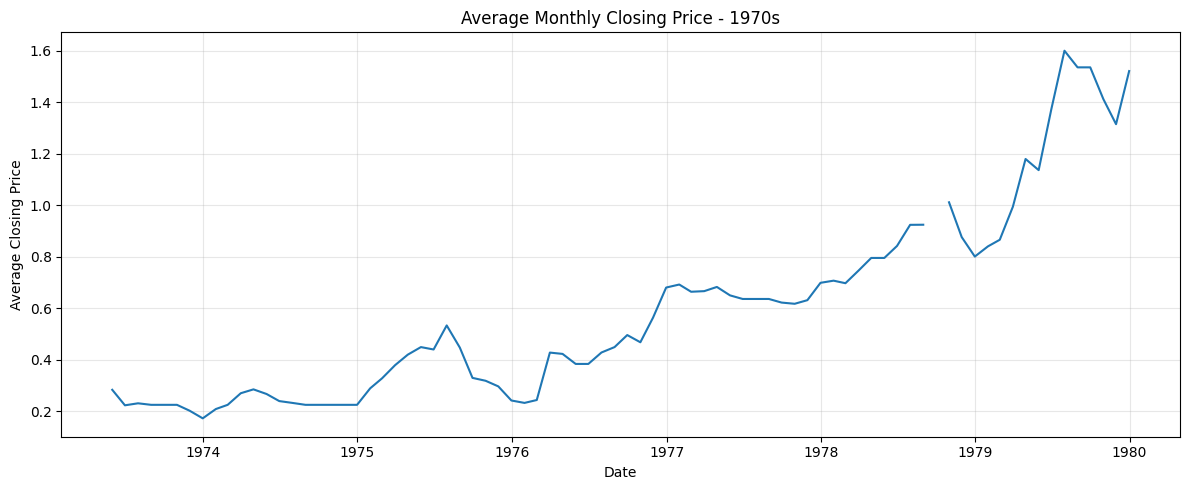

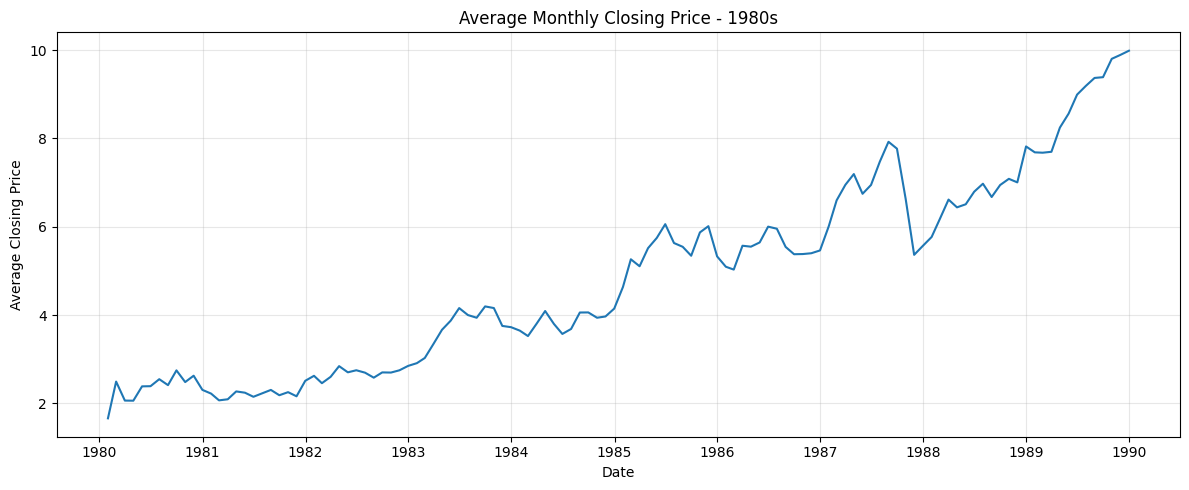

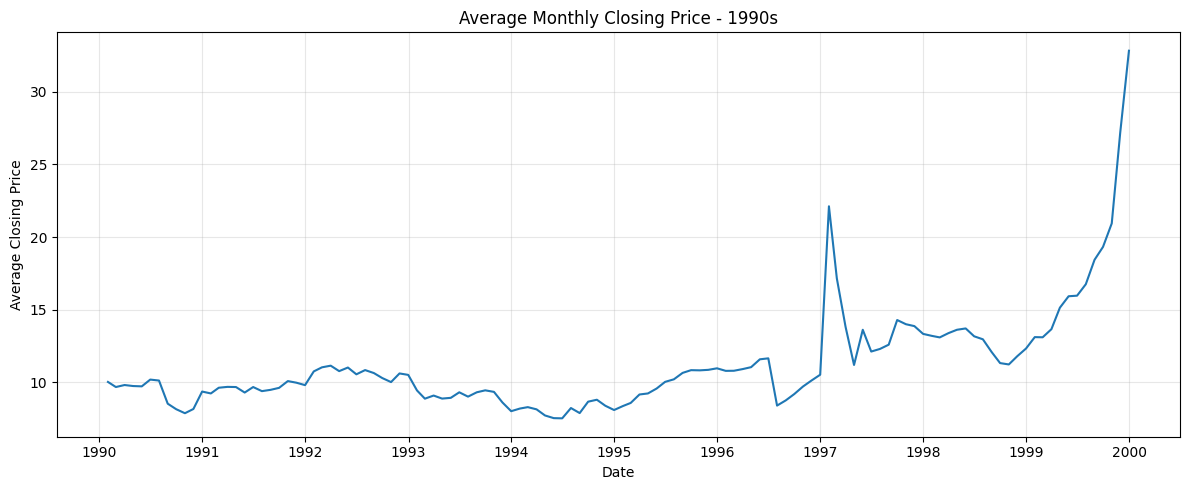

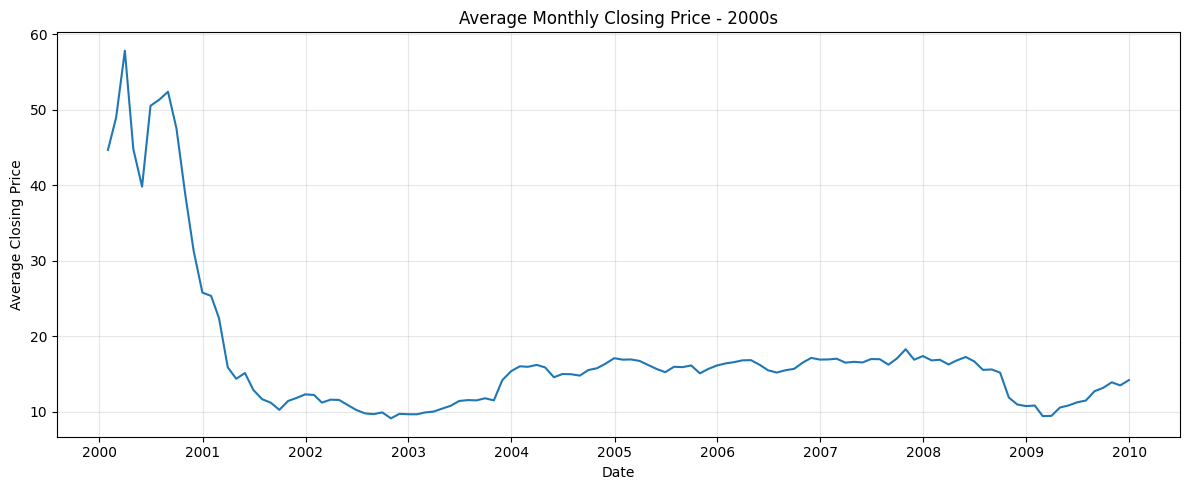

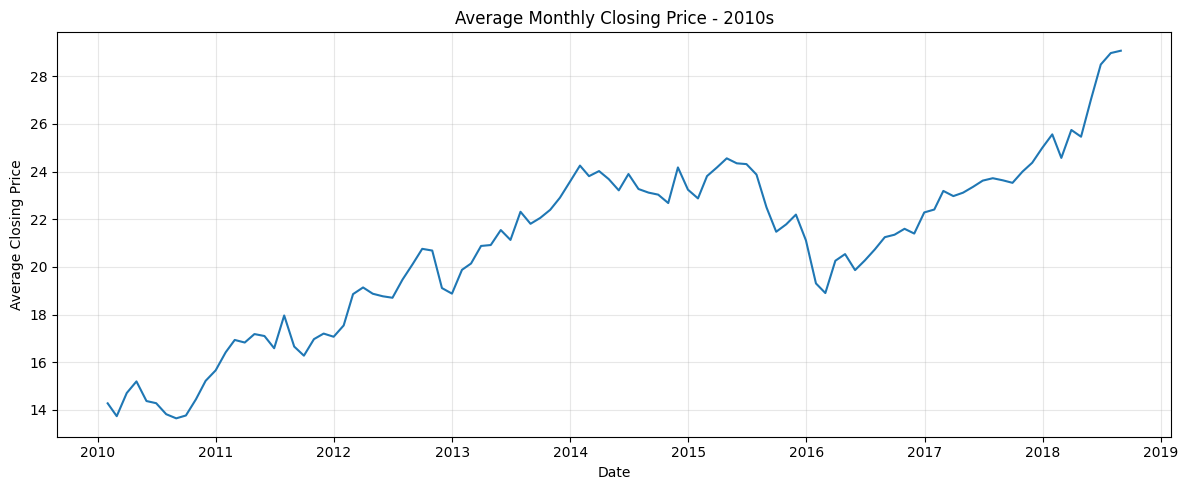

In [ ]:
for decade in sorted(monthly_close['decade'].unique()):

    decade_monthly = monthly_close[monthly_close['decade'] == decade]

    plt.figure(figsize=(12, 5))
    plt.plot(decade_monthly['date'],decade_monthly['close'])

    plt.title(f'Average Monthly Closing Price - {decade}s')
    plt.xlabel('Date')
    plt.ylabel('Average Closing Price')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

9.4 Trading Volume Distribution by Decade

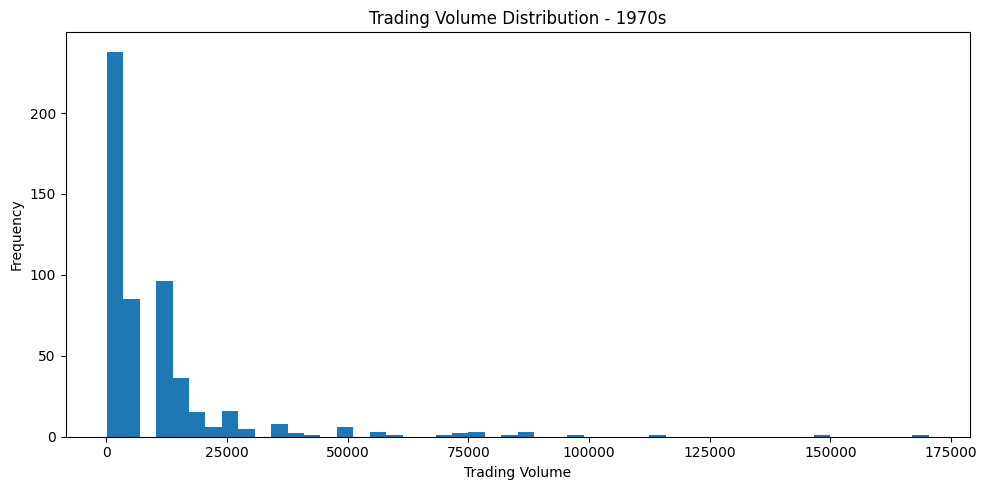

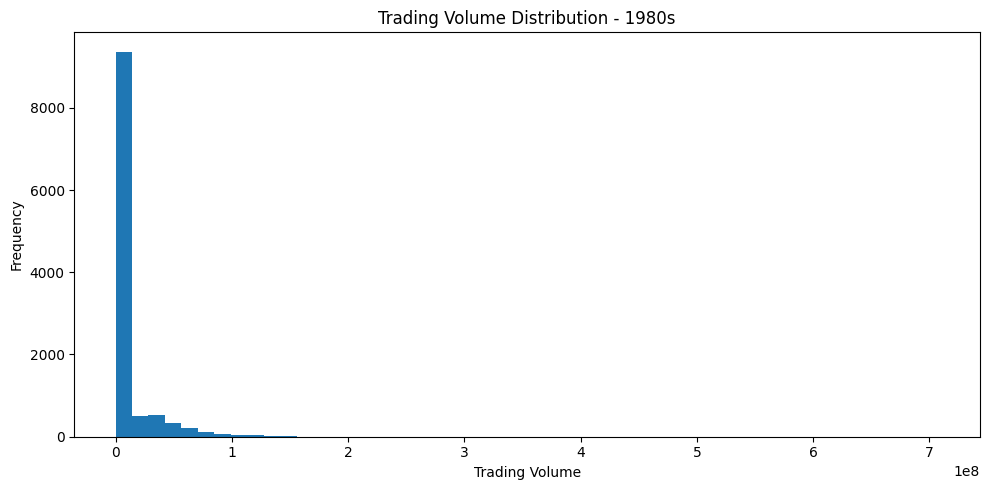

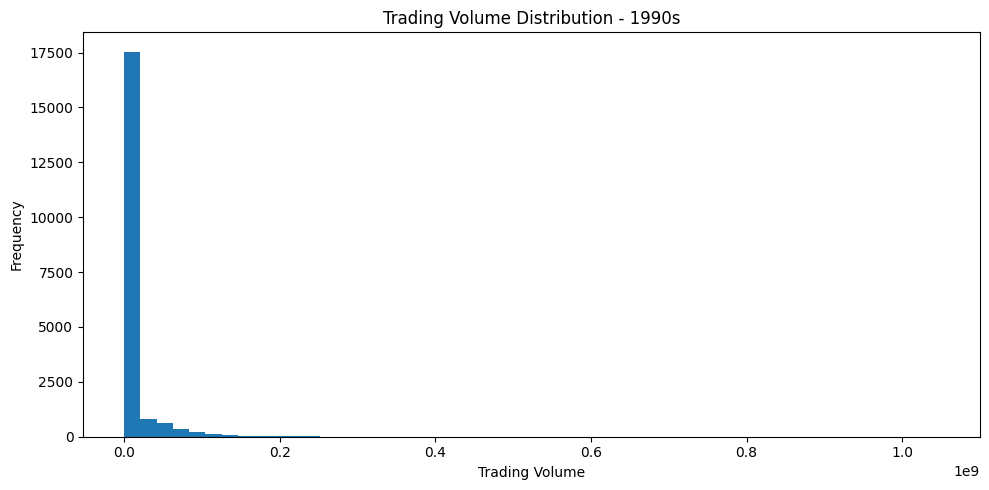

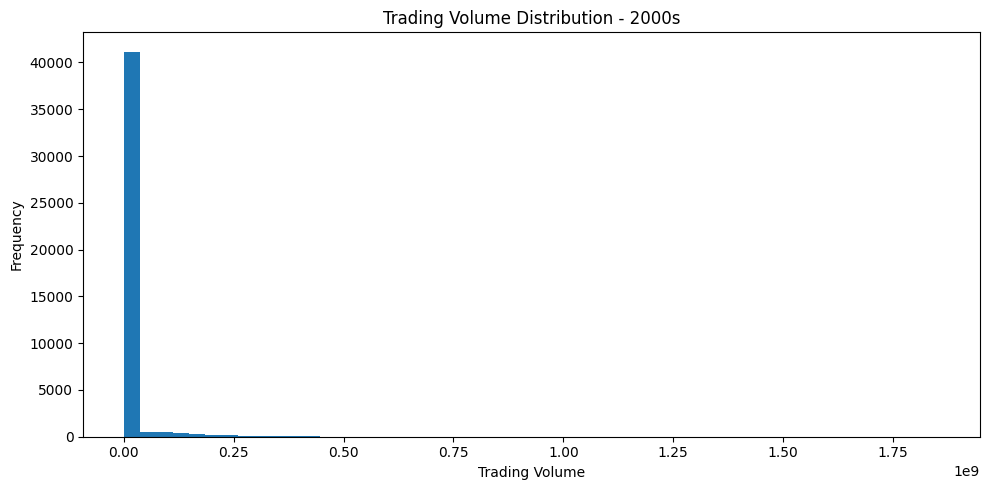

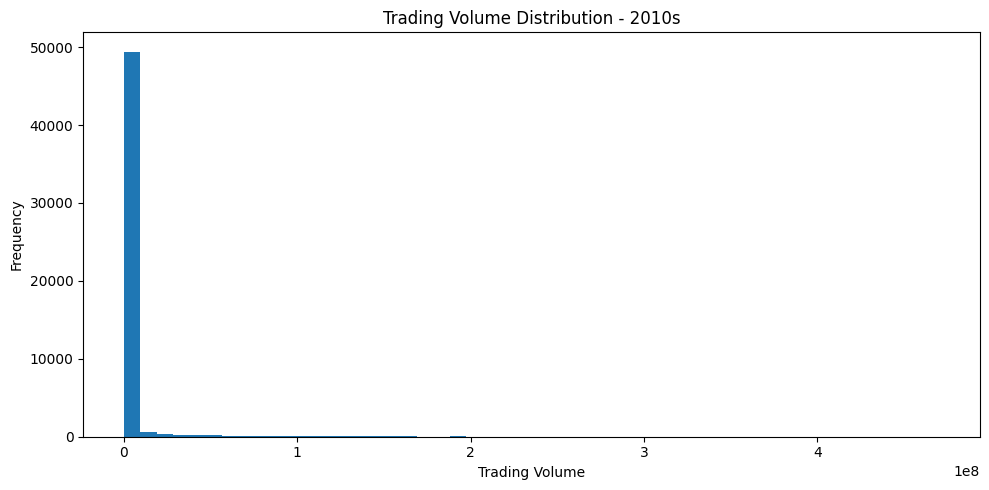

In [ ]:
for decade in sorted(merged_data['decade'].unique()):

    df = merged_data[merged_data['decade'] == decade]

    plt.figure(figsize=(10, 5))
    df['volume'].dropna().plot(kind='hist',bins=50)

    plt.title(f'Trading Volume Distribution - {decade}s')
    plt.xlabel('Trading Volume')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

9.5 High and Low Price Boxplots by Decade

/tmp/ipykernel_7895/3055454637.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df['high'].dropna(),df['low'].dropna()],labels=['High', 'Low'])


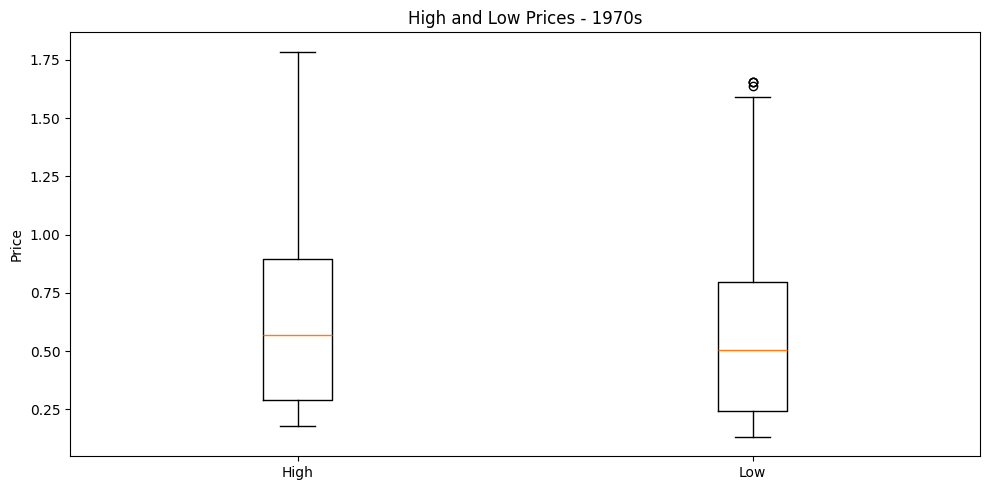

/tmp/ipykernel_7895/3055454637.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df['high'].dropna(),df['low'].dropna()],labels=['High', 'Low'])


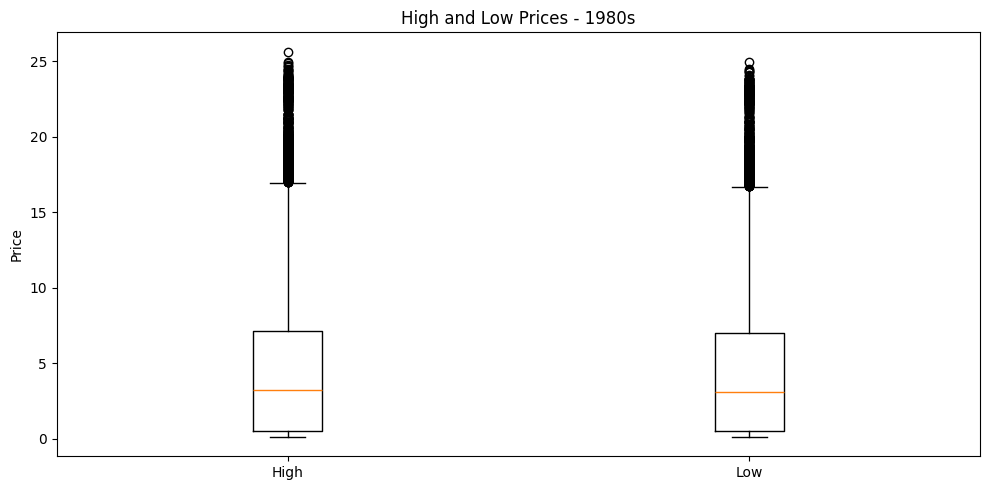

/tmp/ipykernel_7895/3055454637.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df['high'].dropna(),df['low'].dropna()],labels=['High', 'Low'])


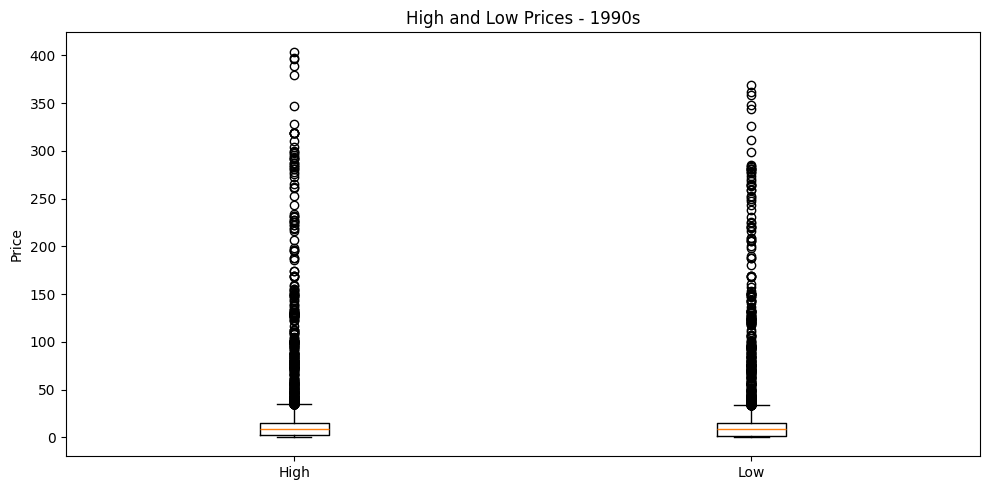

/tmp/ipykernel_7895/3055454637.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df['high'].dropna(),df['low'].dropna()],labels=['High', 'Low'])


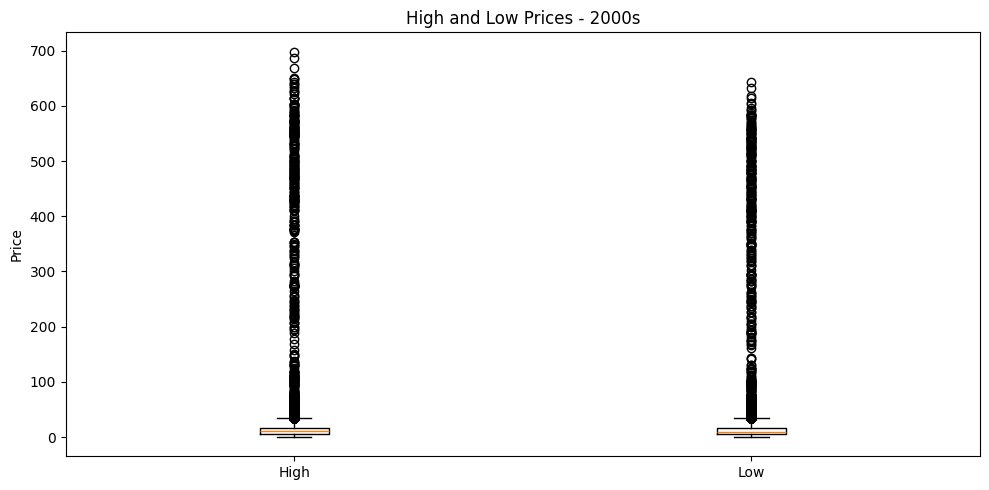

/tmp/ipykernel_7895/3055454637.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df['high'].dropna(),df['low'].dropna()],labels=['High', 'Low'])


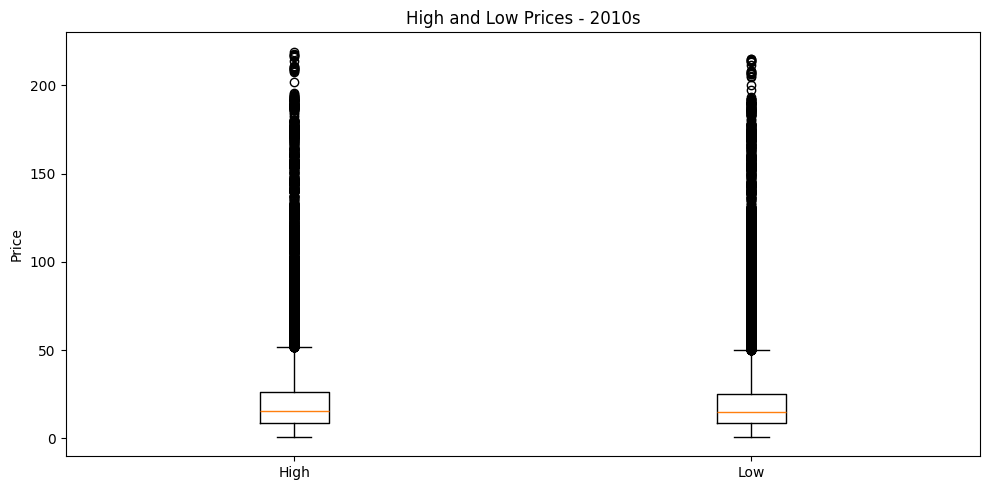

In [ ]:
for decade in sorted(merged_data['decade'].unique()):

    df = merged_data[merged_data['decade'] == decade]

    plt.figure(figsize=(10, 5))
    plt.boxplot([df['high'].dropna(),df['low'].dropna()],labels=['High', 'Low'])

    plt.title(f'High and Low Prices - {decade}s')
    plt.ylabel('Price')
    plt.tight_layout()
    plt.show()

9.6 Comparative Analysis

In [ ]:
# Comparative analysis across decades
comparison = merged_data.groupby('decade').agg(
    mean_close=('close', 'mean'),
    median_close=('close', 'median'),
    std_close=('close', 'std'),
    mean_volume=('volume', 'mean'),
    median_volume=('volume', 'median'),
    std_volume=('volume', 'std'))

print("Comparison of Stock Prices and Trading Volume by Decade:")
display(comparison)

Comparison of Stock Prices and Trading Volume by Decade:


,mean_close,median_close,std_close,mean_volume,median_volume,std_volume
decade,,,,,,
1970,0.612666,0.504924,0.416452,1.043195e+04,3700.0,1.788369e+04
1980,5.003107,3.125000,5.533612,8.267961e+06,74200.0,2.258225e+07
1990,11.921614,8.750000,18.846594,9.027603e+06,75850.0,3.349476e+07
2000,16.651791,9.955000,37.615792,9.620866e+06,109000.0,4.514401e+07
2010,21.167945,15.100000,22.178220,4.174873e+06,166400.0,2.045641e+07


Interpretation of Comparative Analysis

The decade analysis shows changes in stock prices and trading volume over time. The differences between the mean and median indicate the effect of extreme values. The plot also show changes in monthly prices, trading volume, and price ranges across decades.

Interpretation of Comparative Analysis

Stock prices generally increased across the decades. The average closing price rising from $0.61 in the 1970s to $21.17 in the 2010s. Trading volume also changed significantly. The higher standard deviation in the 1990s and 2000s indicates greater variation in closing prices. In conclusion, the results show increasing prices and changes in trading activity over time

9.7 Sector Information by Decade

In [ ]:
sector_by_decade = pd.crosstab(merged_data['decade'],merged_data['sector'])

print("Number of Price Observations by Sector and Decade:")
display(sector_by_decade)

Number of Price Observations by Sector and Decade:


sector,CAPITAL GOODS,CONSUMER DURABLES,CONSUMER NON-DURABLES,CONSUMER SERVICES,ENERGY,FINANCE,HEALTH CARE,MISCELLANEOUS,PUBLIC UTILITIES,TECHNOLOGY
decade,,,,,,,,,,
1970,0,0,0,0,0,532,0,0,0,0
1980,2038,293,0,0,0,2139,0,2476,0,4015
1990,2378,500,0,1458,1829,1735,0,1642,631,6578
2000,4055,2252,2028,6055,2515,6744,1072,0,2960,7545
2010,4353,1863,2177,8682,2177,10961,2177,0,4002,6417


Decade Analysis Summary

In [ ]:

print("DECADE ANALYSIS SUMMARY")
print("_" * 70)

print("\nObservations by Decade:")
for decade, df in decades.items():
    print(f"{decade}s: {len(df):,}")

print("\nAverage closing price by Decade:")
print(merged_data.groupby('decade')['close'].mean().round(2))

print("\nMedian closing price by decade:")
print(merged_data.groupby('decade')['close'].median().round(2))

print("\nAverage trading volume by decade:")
print(merged_data.groupby('decade')['volume'].mean().round(2))

print("\nStandard deviation of closing price by decade:")
print(merged_data.groupby('decade')['close'].std().round(2))

DECADE ANALYSIS SUMMARY
______________________________________________________________________

Observations by Decade:
1970s: 532
1980s: 11,241
1990s: 19,948
2000s: 43,633
2010s: 52,223

Average closing price by Decade:
decade
1970     0.61
1980     5.00
1990    11.92
2000    16.65
2010    21.17
Name: close, dtype: float64

Median closing price by decade:
decade
1970     0.50
1980     3.12
1990     8.75
2000     9.95
2010    15.10
Name: close, dtype: float64

Average trading volume by decade:
decade
1970      10431.95
1980    8267960.56
1990    9027602.73
2000    9620865.88
2010    4174872.62
Name: volume, dtype: float64

Standard deviation of closing price by decade:
decade
1970     0.42
1980     5.53
1990    18.85
2000    37.62
2010    22.18
Name: close, dtype: float64
